# Emotion Classification from Text
Is notebook mein hum `dataset.csv` (Email_Text, Emotion) par ek text-based Emotion Classification model banayenge.

**Workflow:**
1. Data Load + EDA
2. Text Preprocessing (Cleaning)
3. Label Encoding (Target)
4. Train-Test Split
5. TF-IDF Vectorization
6. Multiple Models Train karna (Logistic Regression, Naive Bayes, Random Forest, SVM)
7. Best Model Select karna
8. Sample Prediction (naya text dekar emotion predict karna)


In [1]:
# ── Imports ──────────────────────────────────────────────────────────────
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")


## 1. Load Data & Explore

In [2]:
# ── Load Data ──────────────────────────────────────────────────────────────
df = pd.read_csv('dataset.csv')

print("Shape     :", df.shape)
print("Columns   :", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

print("\nInfo:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())


Shape     : (10000, 2)
Columns   : ['Email_Text', 'Emotion']

First 5 rows:
                          Email_Text  Emotion
0  Please confirm your availability.  Neutral
1             I sincerely apologize.  Apology
2     I feel stressed about my work.      Sad
3               I am feeling lonely.      Sad
4  I am very happy with the service.    Happy

Info:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Email_Text  10000 non-null  str  
 1   Emotion     10000 non-null  str  
dtypes: str(2)
memory usage: 156.4 KB

Missing values:
Email_Text    0
Emotion       0
dtype: int64

Duplicate rows: 9975


## 2. Exploratory Data Analysis (EDA)

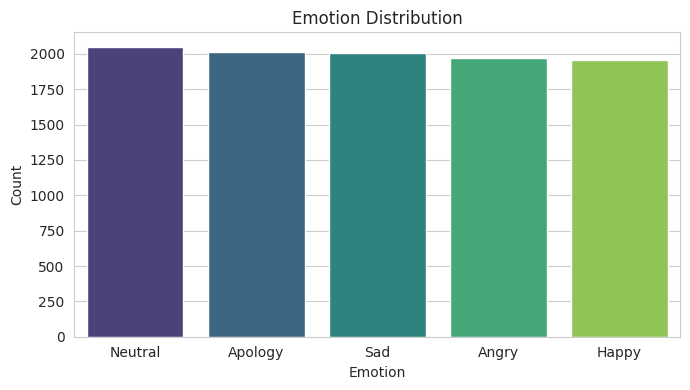

In [3]:
# ── EDA Plot 1: Emotion Distribution ────────────────────────────────────────
plt.figure(figsize=(7,4))
sns.countplot(x='Emotion', data=df, order=df['Emotion'].value_counts().index, palette='viridis')
plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("emotion_distribution.png", dpi=120)
plt.show()


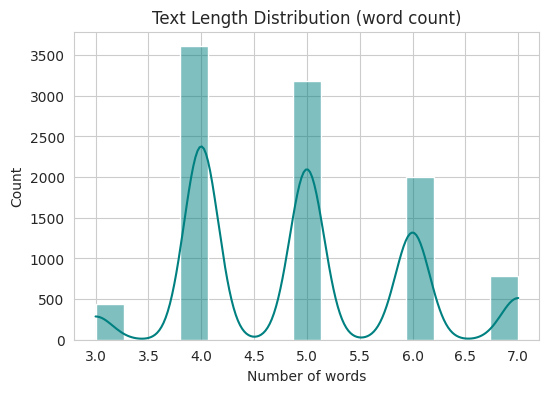

In [4]:
# ── EDA Plot 2: Text Length Distribution ────────────────────────────────────
df['text_length'] = df['Email_Text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(6,4))
sns.histplot(df['text_length'], kde=True, bins=15, color='teal')
plt.title("Text Length Distribution (word count)")
plt.xlabel("Number of words")
plt.show()


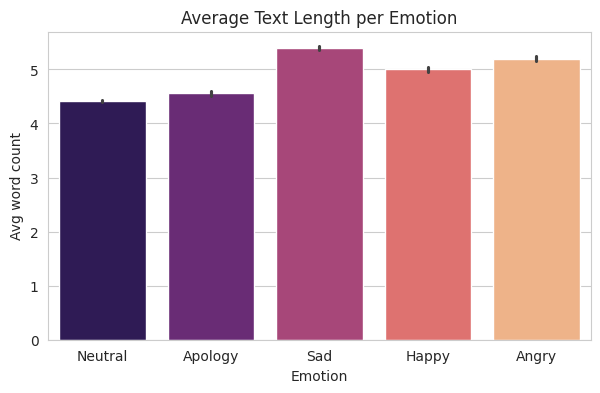

In [5]:
# ── EDA Plot 3: Avg text length per emotion ─────────────────────────────────
plt.figure(figsize=(7,4))
sns.barplot(x='Emotion', y='text_length', data=df, estimator=np.mean, palette='magma')
plt.title("Average Text Length per Emotion")
plt.ylabel("Avg word count")
plt.show()


In [6]:
# ── Unique messages per emotion (sanity check) ──────────────────────────────
print(df.groupby('Emotion')['Email_Text'].nunique())


Emotion
Angry      5
Apology    5
Happy      5
Neutral    5
Sad        5
Name: Email_Text, dtype: int64


## 3. Text Preprocessing
Text ko clean karte hain: lowercase, punctuation remove, extra spaces remove.


In [7]:
# ── Text Cleaning Function ──────────────────────────────────────────────────
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)   # remove punctuation/numbers
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra spaces
    return text

df['Clean_Text'] = df['Email_Text'].apply(clean_text)
df[['Email_Text', 'Clean_Text']].head(10)


,Email_Text,Clean_Text
0,Please confirm your availability.,please confirm your availability
1,I sincerely apologize.,i sincerely apologize
2,I feel stressed about my work.,i feel stressed about my work
3,I am feeling lonely.,i am feeling lonely
4,I am very happy with the service.,i am very happy with the service
5,Your work is excellent.,your work is excellent
6,I am feeling lonely.,i am feeling lonely
7,Please send the report.,please send the report
8,Your work is excellent.,your work is excellent
9,Thank you for your support.,thank you for your support


## 4. Label Encoding (Target Column)

In [8]:
# ── Encode Emotion labels into numbers ──────────────────────────────────────
encoder = LabelEncoder()
df['Emotion_Label'] = encoder.fit_transform(df['Emotion'])

label_mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
print("Label Mapping:", label_mapping)


Label Mapping: {'Angry': np.int64(0), 'Apology': np.int64(1), 'Happy': np.int64(2), 'Neutral': np.int64(3), 'Sad': np.int64(4)}


## 5. Features and Target

In [9]:
# Features and Target
X_text = df['Clean_Text']
y = df['Emotion_Label']


## 6. Train-Test Split

In [10]:
# ── Train-Test Split ─────────────────────────────────────────────────────────
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train_text.shape[0])
print("Test size :", X_test_text.shape[0])


Train size: 8000
Test size : 2000


## 7. TF-IDF Vectorization
Text ko numeric features mein convert karte hain taaki ML models train ho sakein.

In [11]:
# ── TF-IDF Vectorization ─────────────────────────────────────────────────────
tfidf = TfidfVectorizer(max_features=500, ngram_range=(1,2))

X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

print("TF-IDF feature matrix shape (train):", X_train.shape)
print("TF-IDF feature matrix shape (test) :", X_test.shape)


TF-IDF feature matrix shape (train): (8000, 149)
TF-IDF feature matrix shape (test) : (2000, 149)


## 8. Train Multiple Models

In [12]:
# ------------------ Train Multiple Models ------------------

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Linear SVM": LinearSVC(random_state=42)
}

results = []

print("Model Performance\n")

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append([name, acc, f1])

    print(f"{name}: Accuracy = {acc:.4f}, F1 Score = {f1:.4f}")


Model Performance



Logistic Regression: Accuracy = 1.0000, F1 Score = 1.0000
Multinomial Naive Bayes: Accuracy = 1.0000, F1 Score = 1.0000


Random Forest: Accuracy = 1.0000, F1 Score = 1.0000


Linear SVM: Accuracy = 1.0000, F1 Score = 1.0000


## 9. Compare Models

In [13]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1 Score"])
print(results_df)


                     Model  Accuracy  F1 Score
0      Logistic Regression       1.0       1.0
1  Multinomial Naive Bayes       1.0       1.0
2            Random Forest       1.0       1.0
3               Linear SVM       1.0       1.0


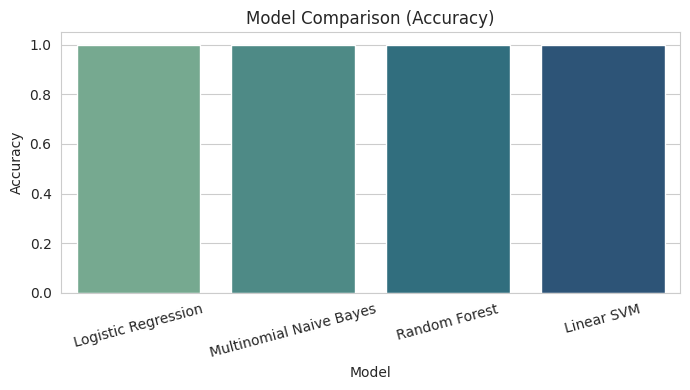

In [14]:
plt.figure(figsize=(7,4))
sns.barplot(x='Model', y='Accuracy', data=results_df, palette='crest')
plt.title("Model Comparison (Accuracy)")
plt.xticks(rotation=15)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()


## 10. Select the Best Model

In [15]:
#Select the Best Model
best_model_row = results_df.loc[results_df["F1 Score"].idxmax()]

print("Best Model")
print(best_model_row)

best = models[best_model_row["Model"]]


Best Model
Model       Logistic Regression
Accuracy                    1.0
F1 Score                    1.0
Name: 0, dtype: object


## 11. Detailed Evaluation of Best Model

Classification Report:

              precision    recall  f1-score   support

       Angry       1.00      1.00      1.00       394
     Apology       1.00      1.00      1.00       403
       Happy       1.00      1.00      1.00       392
     Neutral       1.00      1.00      1.00       410
         Sad       1.00      1.00      1.00       401

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



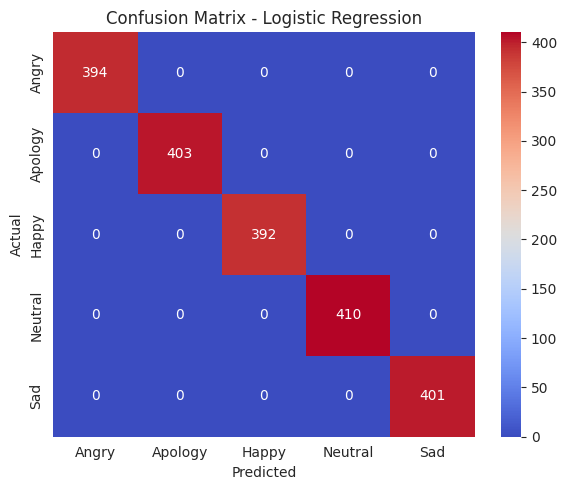

In [16]:
y_pred_best = best.predict(X_test)

print("Classification Report:\n")
print(classification_report(y_test, y_pred_best, target_names=encoder.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="coolwarm",
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title(f"Confusion Matrix - {best_model_row['Model']}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


## 12. Use the Best Model for Prediction
Naya text dekar uska emotion predict karte hain.

In [17]:
def predict_emotion(text):
    cleaned = clean_text(text)
    vec = tfidf.transform([cleaned])
    pred_label = best.predict(vec)[0]
    pred_emotion = encoder.inverse_transform([pred_label])[0]
    return pred_emotion

# ── Sample Predictions ───────────────────────────────────────────────────────
samples = [
    "I am extremely happy with your quick response.",
    "I am really sorry for the delay in the report.",
    "This is so frustrating, nothing is working.",
    "The meeting has been rescheduled to tomorrow.",
    "I feel very sad and lonely today."
]

for text in samples:
    print(f"Text: {text}")
    print(f"Predicted Emotion: {predict_emotion(text)}")
    print("-" * 60)


Text: I am extremely happy with your quick response.
Predicted Emotion: Happy
------------------------------------------------------------
Text: I am really sorry for the delay in the report.
Predicted Emotion: Apology
------------------------------------------------------------
Text: This is so frustrating, nothing is working.
Predicted Emotion: Angry
------------------------------------------------------------
Text: The meeting has been rescheduled to tomorrow.
Predicted Emotion: Neutral
------------------------------------------------------------
Text: I feel very sad and lonely today.
Predicted Emotion: Sad
------------------------------------------------------------
